# Notebook 1 — EDA + CatBoost Baseline

## What this notebook does and why

This is your **Phase 1 + Phase 2** notebook. It does three things in order:

1. **Loads and understands the data** — before writing any model code you need to know what the data actually looks like: what's missing, how imbalanced the labels are, what the columns mean.
2. **Cleans and prepares features** — the raw data has messy strings like `'5ft 4in'` and `'135lbs'` that models can't use directly. We convert them to numbers.
3. **Trains a CatBoost baseline** — this is a fast, strong tree-based model that runs on CPU in minutes. It gives you a **hard benchmark number (macro-F1)** that the LLM fine-tuning must beat before you justify spending GPU money.

**You do not need a GPU for any of this.** Everything here runs on your laptop.

---
**Expected file layout before you start:**
```
ml-resarch/
  data/
    renttherunway_final_data.json
    modcloth_final_data.json
  01_eda_baseline.ipynb   ← this file
```
If you haven't downloaded the data yet, run `python download_data.py` first.

## 0. Install dependencies (run once, then comment out)

In [10]:
# Uncomment and run if you haven't installed these yet
# !pip install pandas scikit-learn catboost matplotlib seaborn pyarrow

## 1. Load the data

The dataset has two separate files:
- **RentTheRunway** — users renting dresses for events. Richer review text, has a `rented_for` column (wedding, party, etc.).
- **ModCloth** — a women's clothing retailer. More complete body measurement data.

Both files are in [JSON Lines format](https://jsonlines.org/) — each line is one review as a JSON object. `lines=True` tells pandas to read it that way instead of treating the whole file as one JSON object.

We load them separately first to understand each one, then combine later.

In [11]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

rtr = pd.read_json('data/renttherunway_final_data.json', lines=True)
mc  = pd.read_json('data/modcloth_final_data.json', lines=True)

print('RentTheRunway shape:', rtr.shape, '  ← (rows, columns)')
print('ModCloth shape:     ', mc.shape)

rtr.head(3)

RentTheRunway shape: (192544, 15)   ← (rows, columns)
ModCloth shape:      (82790, 18)


,fit,user_id,bust size,item_id,weight,rating,rented for,review_text,body type,review_summary,category,height,size,age,review_date
0,fit,420272,34d,2260466,137lbs,10.0,vacation,An adorable romper! Belt and zipper were a lit...,hourglass,So many compliments!,romper,"5' 8""",14,28.0,"April 20, 2016"
1,fit,273551,34b,153475,132lbs,10.0,other,I rented this dress for a photo shoot. The the...,straight & narrow,I felt so glamourous!!!,gown,"5' 6""",12,36.0,"June 18, 2013"
2,fit,360448,NaN,1063761,NaN,10.0,party,This hugged in all the right places! It was a ...,NaN,It was a great time to celebrate the (almost) ...,sheath,"5' 4""",4,116.0,"December 14, 2015"


In [12]:
mc.head(3)

,item_id,waist,size,quality,cup size,hips,bra size,category,bust,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text
0,123373,29.0,7,5.0,d,38.0,34.0,new,36,5ft 6in,Emily,just right,small,991571,NaN,NaN,NaN,NaN
1,123373,31.0,13,3.0,b,30.0,36.0,new,NaN,5ft 2in,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN
2,123373,30.0,7,2.0,b,NaN,32.0,new,NaN,5ft 7in,Ugggh,slightly long,small,395665,9.0,NaN,NaN,NaN


## 2. EDA — Exploratory Data Analysis

### Why EDA before building anything

EDA tells you three things that will affect every decision you make:

1. **Label imbalance** — if 70% of rows are `fit`, a model that predicts `fit` every time gets 70% accuracy while being completely useless for `small` and `large` users. You need to know this before choosing your loss function and evaluation metric.
2. **Missingness** — if `height` is missing for 60% of rows, you can't just drop those rows (you'd lose 60% of data). You need a strategy: add a `has_height` flag so the model learns "no measurement provided" is itself a signal.
3. **Column formats** — are measurements stored as numbers or strings like `'135lbs'`? You can't feed raw strings to a tree model.

In [13]:
for name, df in [('RentTheRunway', rtr), ('ModCloth', mc)]:
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')

    print('\nColumns:', df.columns.tolist())

    print('\nFit label distribution (% of total):')
    print(df['fit'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

    print('\nMissing values per column (% missing):')
    miss = df.isnull().mean().mul(100).round(1)
    print(miss[miss > 0].sort_values(ascending=False))


  RentTheRunway

Columns: ['fit', 'user_id', 'bust size', 'item_id', 'weight', 'rating', 'rented for', 'review_text', 'body type', 'review_summary', 'category', 'height', 'size', 'age', 'review_date']

Fit label distribution (% of total):
fit
fit      73.8%
small    13.4%
large    12.8%
Name: proportion, dtype: str

Missing values per column (% missing):
weight       15.6
bust size     9.6
body type     7.6
age           0.5
height        0.4
dtype: float64

  ModCloth

Columns: ['item_id', 'waist', 'size', 'quality', 'cup size', 'hips', 'bra size', 'category', 'bust', 'height', 'user_name', 'length', 'fit', 'user_id', 'shoe size', 'shoe width', 'review_summary', 'review_text']

Fit label distribution (% of total):
fit
fit      68.6%
large    15.8%
small    15.7%
Name: proportion, dtype: str

Missing values per column (% missing):
waist             96.5
bust              85.7
shoe width        77.5
shoe size         66.3
hips              32.3
review_summary     8.1
review_text       

### Visualise the class imbalance

The bar chart below makes the imbalance concrete. The `fit` bar will be much taller. This is why we:
- Use **macro-F1** as our metric (it weights each class equally regardless of frequency)
- Pass `class_weights` to CatBoost to penalise mistakes on minority classes more heavily

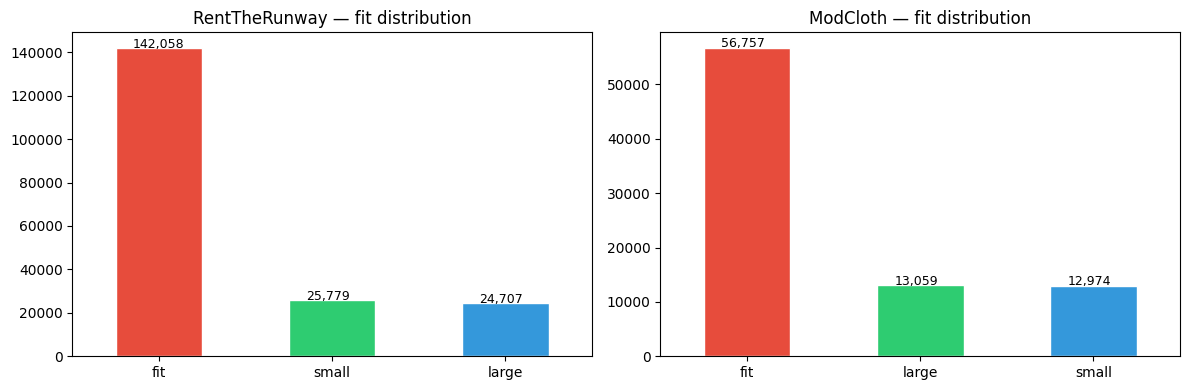

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, df) in zip(axes, [('RentTheRunway', rtr), ('ModCloth', mc)]):
    counts = df['fit'].value_counts()
    counts.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71', '#3498db'], edgecolor='white')
    ax.set_title(f'{name} — fit distribution')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + 0.1, p.get_height() + 50), fontsize=9)
plt.tight_layout()
plt.show()

## 3. Preprocessing — cleaning the raw data

### What we're doing and why

The raw dataset stores measurements as freeform user-typed strings: `'5ft 4in'`, `'135lbs'`, `"5' 4\""`. We need to:

- **Parse height → inches** (e.g. `64.0`). We use regex to handle all the formats users typed.
- **Parse weight → lbs**. Some users typed kg, so we convert.
- **Add missingness flags** (`has_height`, `has_weight`) — when a value is missing, filling with `NaN` hides information. A separate binary column tells the model: "this user did not provide height", which the model can learn from.
- **Map size labels to a numeric scale** so the model understands XS < S < M < L. Without this, tree models treat them as unordered categories.
- **Drop invalid fit labels** — anything not in `{small, fit, large}` (nulls, typos, other values) is useless for training.

In [15]:
import re

def parse_height(h):
    """
    Converts height strings to total inches.
    Handles: '5ft 4in', "5' 4\"", '5ft', bare numbers
    Returns NaN if unparseable.
    """
    if pd.isna(h):
        return np.nan
    h = str(h)
    ft    = re.search(r'(\d+)\s*ft', h)
    inch  = re.search(r'(\d+)\s*in', h)
    ft2   = re.search(r"(\d+)'", h)
    inch2 = re.search(r'(\d+)"', h)
    feet   = int((ft or ft2).group(1))    if (ft or ft2)     else 0
    inches = int((inch or inch2).group(1)) if (inch or inch2) else 0
    return feet * 12 + inches if (feet or inches) else np.nan

def parse_weight(w):
    """
    Converts weight strings to lbs.
    Handles: '135lbs', '61kg', bare numbers (assumed lbs).
    """
    if pd.isna(w):
        return np.nan
    w   = str(w)
    kg  = re.search(r'([\d.]+)\s*kg', w, re.I)
    lb  = re.search(r'([\d.]+)\s*lb', w, re.I)
    num = re.search(r'([\d.]+)', w)
    if kg:
        return float(kg.group(1)) * 2.205
    if lb:
        return float(lb.group(1))
    return float(num.group(1)) if num else np.nan

# Quick sanity checks before running on the full dataset
print('Height parser tests:')
for s in ["5ft 4in", "5' 4\"", "5ft", None, "64"]:
    print(f'  {repr(s):15} → {parse_height(s)}')

print('\nWeight parser tests:')
for s in ["135lbs", "61kg", "150", None]:
    print(f'  {repr(s):15} → {parse_weight(s)}')

Height parser tests:
  '5ft 4in'       → 64
  '5\' 4"'        → 64
  '5ft'           → 60
  None            → nan
  '64'            → nan

Weight parser tests:
  '135lbs'        → 135.0
  '61kg'          → 134.505
  '150'           → 150.0
  None            → nan


In [17]:
def preprocess(df, source_name):
    df = df.copy()

    # 0. Normalize column names: replace spaces with underscores
    #    RTR has columns like 'body type', 'bust size', 'rented for' — pandas is fine with
    #    spaced names but they're painful to type and easy to mistype
    df.columns = df.columns.str.strip().str.replace(' ', '_')

    df['source'] = source_name

    # 1. Keep only rows with a valid fit label
    before = len(df)
    df = df[df['fit'].isin(['small', 'fit', 'large'])].copy()
    print(f'{source_name}: dropped {before - len(df)} rows with invalid fit labels')

    # 2. Parse height (present in both datasets)
    df['height_in'] = df['height'].apply(parse_height)

    # 3. Weight — RTR has 'weight' column, ModCloth does not (it has waist/hips/bust instead)
    #    For ModCloth rows weight_lbs will be NaN, which becomes -1 below
    if 'weight' in df.columns:
        df['weight_lbs'] = df['weight'].apply(parse_weight)
    else:
        df['weight_lbs'] = np.nan

    # 4. Missingness indicators — the model can learn that "no weight provided" is a signal
    df['has_height'] = df['height_in'].notna().astype(int)
    df['has_weight'] = df['weight_lbs'].notna().astype(int)

    # 5. Fill NaN measurements with -1
    #    Using -1 (not 0 or median) because it's clearly out-of-range — the model
    #    won't confuse it with a real measurement value
    df['height_in']  = df['height_in'].fillna(-1)
    df['weight_lbs'] = df['weight_lbs'].fillna(-1)

    # 6. Review text — ensure always a string, add length as a feature
    df['review_text'] = df['review_text'].fillna('').astype(str)
    df['review_len']  = df['review_text'].str.split().str.len()

    # 7. Rating — RTR has 'rating' (1-10), ModCloth has 'quality' (1-5)
    #    Normalise both to a 0-1 scale so they're on the same range when combined
    if 'rating' in df.columns:
        df['rating_norm'] = pd.to_numeric(df['rating'], errors='coerce') / 10.0
    elif 'quality' in df.columns:
        df['rating_norm'] = pd.to_numeric(df['quality'], errors='coerce') / 5.0
    else:
        df['rating_norm'] = np.nan

    # 8. Size — both datasets use numeric dress sizes (4, 6, 8, 12, 14...)
    #    Cast directly to float; non-numeric entries (like 'XS') become NaN
    df['size_num'] = pd.to_numeric(df['size'], errors='coerce')

    return df

rtr_clean = preprocess(rtr, 'rtr')
mc_clean  = preprocess(mc,  'mc')

df = pd.concat([rtr_clean, mc_clean], ignore_index=True)
print(f'\nCombined dataset: {len(df):,} rows')
print('\nFinal fit distribution:')
print(df['fit'].value_counts())
print('\nSample of cleaned columns:')
print(df[['source','fit','height_in','weight_lbs','has_height','has_weight','size_num','rating_norm']].head(4))

rtr: dropped 0 rows with invalid fit labels
mc: dropped 0 rows with invalid fit labels

Combined dataset: 275,334 rows

Final fit distribution:
fit
fit      198815
small     38753
large     37766
Name: count, dtype: int64

Sample of cleaned columns:
  source  fit  height_in  weight_lbs  has_height  has_weight  size_num  \
0    rtr  fit       68.0       137.0           1           1        14   
1    rtr  fit       66.0       132.0           1           1        12   
2    rtr  fit       64.0        -1.0           1           0         4   
3    rtr  fit       65.0       135.0           1           1         8   

   rating_norm  
0          1.0  
1          1.0  
2          1.0  
3          0.8  


## 4. Train / Validation / Test split

### Why time-based and not random?

**Random splits leak the future into training** — this is the most common mistake in recommendation ML.

Imagine user A reviews item X in December saying *"runs small, size up"*. That same item has similar reviews from October. A random split might put the December review in training and an October review in test. The model learns from a future signal it wouldn't have in real life.

In production you'll predict fit for *new* purchases. Your test set should simulate exactly that: data from the future relative to training.

**Split: 70% train → 15% validation → 15% test (ordered by time)**
- **Train**: what the model learns from
- **Validation**: used during training to decide when to stop (early stopping)
- **Test**: never touched until final evaluation — this is your unbiased performance number

In [18]:
date_cols = [c for c in df.columns if 'date' in c.lower() or 'time' in c.lower()]
print('Date-like columns found:', date_cols)

if date_cols:
    print(f'Sorting by: {date_cols[0]}')
    print(df[date_cols[0]].describe())
    df = df.sort_values(date_cols[0]).reset_index(drop=True)
else:
    print('No date column — using row order as proxy (ModCloth first, RentTheRunway second)')

Date-like columns found: ['review_date']
Sorting by: review_date
count            192544
unique             2274
top       June 15, 2016
freq                844
Name: review_date, dtype: object


In [19]:
n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print('Split sizes and fit distributions:')
for name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    dist = split['fit'].value_counts(normalize=True).mul(100).round(1)
    print(f'  {name:6}: {len(split):7,} rows  |  {dist.to_dict()}')

Split sizes and fit distributions:
  train : 192,733 rows  |  {'fit': 73.8, 'small': 13.4, 'large': 12.8}
  val   :  41,300 rows  |  {'fit': 70.4, 'small': 15.6, 'large': 14.0}
  test  :  41,301 rows  |  {'fit': 66.8, 'large': 17.5, 'small': 15.7}


## 5. Feature engineering

### Why we're replacing TF-IDF with sentence embeddings

The baseline used TF-IDF which treats words as independent tokens. The problem: `"runs small"` and `"fits really small"` and `"too tight on me"` all mean the same thing but look completely different to TF-IDF. This caused the train/val gap (0.73 vs 0.59) — the model memorised specific phrasings instead of learning the meaning.

**Sentence embeddings** (via `sentence-transformers`) run each review through a small pre-trained transformer and output a 384-dimensional vector where semantically similar reviews land close together in vector space. `"runs small"` and `"too tight"` will have similar vectors.

`all-MiniLM-L6-v2` is the standard go-to: 80 MB, fast on CPU (~3 min for 200k reviews), and punches well above its weight for short text like reviews.

**No leakage risk here** — unlike TF-IDF which needs to `fit()` a vocabulary, sentence embeddings use a pre-trained model that never sees your data. We just call `encode()` on each split independently.

In [ ]:
from sentence_transformers import SentenceTransformer
from scipy.sparse import hstack, csr_matrix
import numpy as np

# Install if needed: pip install sentence-transformers
# Model is ~80MB, downloads once and caches in ~/.cache/torch/sentence_transformers/
embedder = SentenceTransformer('all-MiniLM-L6-v2')

TABULAR_COLS = ['height_in', 'weight_lbs', 'has_height', 'has_weight', 'review_len', 'size_num', 'rating_norm']

print('Encoding reviews with sentence embeddings (this takes ~3 min on CPU)...')
print(f'  train: {len(train_df):,} reviews')
train_emb = embedder.encode(train_df['review_text'].tolist(), batch_size=256, show_progress_bar=True)
print(f'  val:   {len(val_df):,} reviews')
val_emb   = embedder.encode(val_df['review_text'].tolist(),   batch_size=256, show_progress_bar=True)
print(f'  test:  {len(test_df):,} reviews')
test_emb  = embedder.encode(test_df['review_text'].tolist(),  batch_size=256, show_progress_bar=True)

# Each embedding is a 384-dim float32 vector — shape: (n_rows, 384)
print(f'\nEmbedding shape per split: {train_emb.shape}')

def make_features(split, emb):
    # Tabular block: 7 numeric columns
    tab = split[TABULAR_COLS].fillna(-1).values.astype(np.float32)
    # Stack tabular (7 cols) + embedding (384 cols) = 391 features total
    return hstack([csr_matrix(tab), csr_matrix(emb)])

X_train = make_features(train_df, train_emb)
X_val   = make_features(val_df,   val_emb)
X_test  = make_features(test_df,  test_emb)

label_map = {'small': 0, 'fit': 1, 'large': 2}
y_train = train_df['fit'].map(label_map)
y_val   = val_df['fit'].map(label_map)
y_test  = test_df['fit'].map(label_map)

print('\nFeature matrix shapes:')
print(f'  X_train: {X_train.shape}  ({len(TABULAR_COLS)} tabular + 384 embedding = {X_train.shape[1]} features)')
print(f'  X_val:   {X_val.shape}')
print(f'  X_test:  {X_test.shape}')

## 6. Train the CatBoost baseline

### Why CatBoost?

CatBoost is a gradient boosting tree model. For tabular + text problems like this it:
- Typically outperforms logistic regression and random forests out of the box
- Trains in minutes on CPU (no GPU needed)
- Handles missing values gracefully
- Gives reliable feature importance scores

It's the standard "try first" model for structured data.

### Key parameters explained
| Parameter | Value | Why |
|---|---|---|
| `class_weights` | `[1.5, 0.4, 1.5]` | Mistakes on `small`/`large` cost 1.5x more. Without this the model optimises for the majority `fit` class. |
| `eval_metric` | `TotalF1` | Macro-F1 on validation — the number we actually care about. |
| `early_stopping_rounds` | `50` | Stop if val macro-F1 hasn't improved for 50 rounds. Prevents overfitting without guessing the iteration count. |
| `loss_function` | `MultiClass` | Tells CatBoost this is a 3-class problem, not binary. |

In [21]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='MultiClass',
    class_weights=[1.5, 0.4, 1.5],
    eval_metric='TotalF1',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100,
)

print('Training CatBoost... (2-5 min on CPU)')
model.fit(X_train, y_train, eval_set=(X_val, y_val))
print('Done.')

Training CatBoost... (2-5 min on CPU)
0:	learn: 0.6254642	test: 0.5202264	best: 0.5202264 (0)	total: 802ms	remaining: 13m 21s
100:	learn: 0.6928787	test: 0.5736173	best: 0.5739347 (92)	total: 1m 16s	remaining: 11m 20s
200:	learn: 0.7044919	test: 0.5803836	best: 0.5804501 (198)	total: 2m 37s	remaining: 10m 25s
300:	learn: 0.7129070	test: 0.5834554	best: 0.5835546 (298)	total: 3m 57s	remaining: 9m 11s
400:	learn: 0.7192984	test: 0.5860037	best: 0.5860077 (399)	total: 5m 20s	remaining: 7m 59s
500:	learn: 0.7251220	test: 0.5883666	best: 0.5884959 (494)	total: 6m 33s	remaining: 6m 31s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5884959075
bestIteration = 494

Shrink model to first 495 iterations.
Done.


## 7. Evaluate on the held-out test set

### How to read the classification report

```
              precision    recall  f1-score   support
       small       0.xx      0.xx      0.xx      NNN
         fit       0.xx      0.xx      0.xx      NNN
       large       0.xx      0.xx      0.xx      NNN
    macro avg       0.xx      0.xx      0.xx      NNN
```

- **Precision for `small`**: of all times the model predicted `small`, what % was correct?
- **Recall for `small`**: of all actual `small` items, what % did the model catch?
- **F1**: harmonic mean of precision and recall — punishes having one high and one low
- **Macro avg F1**: unweighted average F1 across all 3 classes → **your headline number**

**Watch the recall for `small` and `large`.** Low recall on `small` = users ordering items too small for them and the model missing it. That's a real-world return.

=== TEST SET RESULTS — BASELINE ===
              precision    recall  f1-score   support

       small       0.44      0.63      0.52      6481
         fit       0.85      0.65      0.73     27576
       large       0.38      0.58      0.46      7244

    accuracy                           0.63     41301
   macro avg       0.56      0.62      0.57     41301
weighted avg       0.70      0.63      0.65     41301



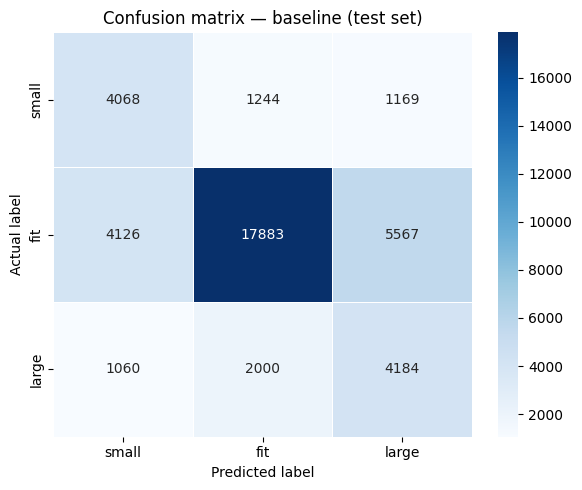

In [22]:
preds = model.predict(X_test).flatten()
names = ['small', 'fit', 'large']

print('=== TEST SET RESULTS — BASELINE ===')
print(classification_report(y_test, preds, target_names=names))

# Confusion matrix: rows = actual label, columns = predicted label
# Off-diagonal = mistakes. Common pattern: 'small' confused as 'fit'
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=names, yticklabels=names,
            cmap='Blues', linewidths=0.5)
plt.title('Confusion matrix — baseline (test set)')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

### Save the macro-F1 — this is your gate metric

This number is the **most important output of this entire notebook**. Every GPU dollar you spend on QLoRA is only justified if the LLM beats this number by at least 0.03.

We write it to `results/baseline.json` so the LLM notebook can load it automatically and tell you whether fine-tuning helped.

In [ ]:
from sklearn.metrics import f1_score
import json, pathlib

macro_f1     = f1_score(y_test, preds, average='macro')
per_class_f1 = f1_score(y_test, preds, average=None)  # [small, fit, large]

# Load previous TF-IDF baseline for comparison
prev = {}
prev_path = pathlib.Path('results/baseline.json')
if prev_path.exists():
    prev = json.load(open(prev_path))

print(f'\n{"*"*52}')
print(f'  IMPROVED BASELINE (sentence embeddings)')
print(f'{"*"*52}')
print(f'  Macro-F1  :  {macro_f1:.4f}', end='')
if prev:
    delta = macro_f1 - prev["baseline_macro_f1"]
    print(f'   ({delta:+.4f} vs TF-IDF baseline of {prev["baseline_macro_f1"]})')
else:
    print()
print(f'  F1 small  :  {per_class_f1[0]:.4f}')
print(f'  F1 fit    :  {per_class_f1[1]:.4f}')
print(f'  F1 large  :  {per_class_f1[2]:.4f}')
print(f'{"*"*52}')
print(f'\n→ LLM must beat macro-F1 > {macro_f1 + 0.03:.4f} to justify GPU spend.')

pathlib.Path('results').mkdir(exist_ok=True)
result = {
    'baseline_macro_f1':      round(macro_f1, 4),
    'baseline_small_f1':      round(float(per_class_f1[0]), 4),
    'baseline_large_f1':      round(float(per_class_f1[2]), 4),
    'llm_target_macro_f1':    round(macro_f1 + 0.03, 4),
    'tfidf_baseline_macro_f1': prev.get('baseline_macro_f1', 'N/A'),
    'features': 'tabular + sentence-embeddings (all-MiniLM-L6-v2)',
}
json.dump(result, open('results/baseline.json', 'w'), indent=2)
print('\nSaved to results/baseline.json')

## 8. Feature importance

### What to look for

Feature importance shows which inputs the model relied on most. Useful for two things:

1. **Sanity check** — if `has_height` (a missingness flag) is the top feature, something may be off. If `runs_small` (a TF-IDF bigram) is top, that makes intuitive sense and validates the approach.
2. **LLM prompt design** — the most important features here should appear prominently in your LLM prompts. If review text dominates but height barely matters, your LLM should focus on parsing the review.

Top 20 features:
size_num       9.17
large          7.86
small          7.46
tight          6.55
rating_norm    6.12
big            5.74
true to        5.10
weight_lbs     5.08
runs           3.86
size           3.66
down           3.20
size up        2.70
up             2.52
snug           2.17
loose          1.44
fit            1.15
usually        1.14
smaller        1.09
short          1.08
wear           0.66


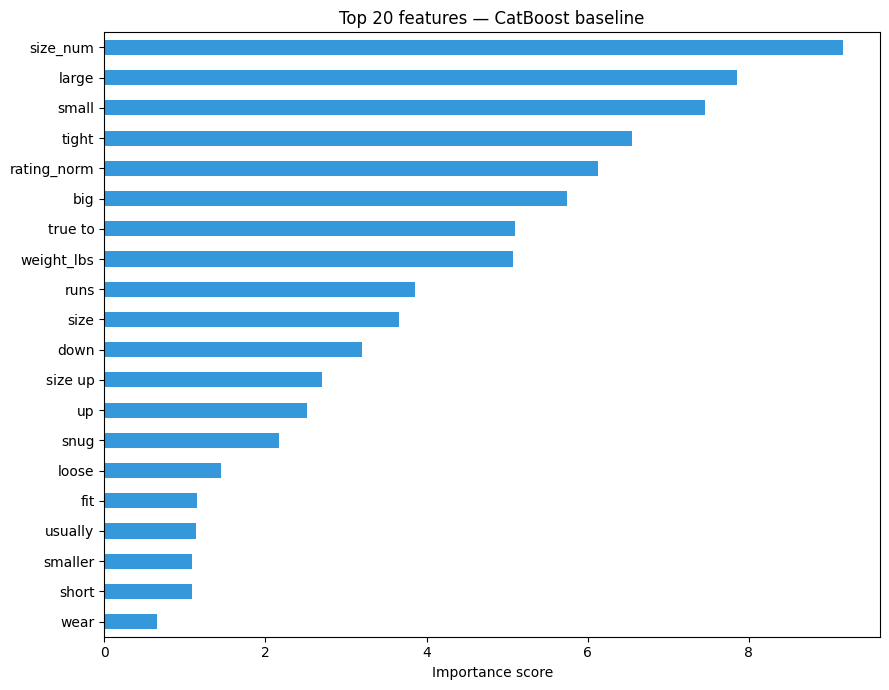

In [24]:
feature_names = TABULAR_COLS + tfidf.get_feature_names_out().tolist()
importances   = model.get_feature_importance()

fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print('Top 20 features:')
print(fi.head(20).round(2).to_string())

fi.head(20).sort_values().plot(
    kind='barh', figsize=(9, 7),
    title='Top 20 features — CatBoost baseline',
    color='#3498db'
)
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

## 9. Save processed splits for the LLM notebook

We save the cleaned `train/val/test` splits as **Parquet** files. The LLM notebook needs these to build prompts — it needs the original text columns (`review_text`, `body_type`, etc.), not just the feature matrix we built above.

Parquet is a columnar binary format: ~5x faster to read/write than CSV for large files, and it preserves column dtypes (so `int` stays `int`, not a string).

In [25]:
keep_cols = [
    'fit', 'height_in', 'weight_lbs', 'has_height', 'has_weight',
    'body_type', 'age', 'bust_size', 'size', 'size_num',
    'category', 'review_text', 'review_summary', 'rating', 'source'
]

for name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    cols = [c for c in keep_cols if c in split.columns]
    split[cols].to_parquet(f'data/{name}.parquet', index=False)
    print(f'Saved data/{name}.parquet — {len(split):,} rows, {len(cols)} columns')

print('\n✓ Notebook complete.')
print('  Check results/baseline.json for your gate metric.')
print('  Next: run 02_llm_finetune.ipynb on a GPU instance (bring data/*.parquet with you).')

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.